<a href="https://colab.research.google.com/github/SupriyaSakshana/Shopper-Spectrum-Customer-Segmentation-and-Product-Recommendations-in-E-Commerce/blob/main/Shopper_Spectrum_Customer_Segmentation_and_Product_Recommendations_in_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# **Project Name**    -  Shopper-Spectrum-Customer-Segmentation-and-Product-Recommendations-in-E-Commerce



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual

# **Project Summary -**

I analyzed e-commerce transaction data, performed RFM analysis to understand customer behavior, and used K-Means clustering to segment customers into business-friendly groups such as High-Value, Regular, Occasional, and At-Risk customers. Additionally, I built an item-based collaborative filtering recommendation system using cosine similarity to recommend products based on historical purchase patterns. Finally, I deployed both functionalities in a Streamlit application for real-time predictions and recommendations.

# **GitHub Link -**

https://github.com/SupriyaSakshana/Shopper-Spectrum-Customer-Segmentation-and-Product-Recommendations-in-E-Commerce.git

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.metrics.pairwise import cosine_similarity

import pickle

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

### Dataset First View

In [ ]:
dataset = pd.read_csv('/content/online_retail.csv', engine='python', on_bad_lines='skip')

In [ ]:
dataset = pd.read_csv('online_retail.csv', engine='python', on_bad_lines='skip')
# Dataset First Look
dataset.head()

### Dataset Rows & Columns count

In [ ]:
print(f"Number of rows: {dataset.shape[0]}")
print(f"Number of columns: {dataset.shape[1]}")

### Dataset Information

In [ ]:
# Dataset Info

dataset.info()


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
len(dataset[dataset.duplicated()])

In [ ]:
dataset[dataset.duplicated()].head()

In [ ]:
dataset.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {dataset.shape[0]}")

In [ ]:
print(dataset.duplicated().sum())

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
dataset.isnull().sum()

In [ ]:
print(dataset.isnull().sum())

In [ ]:
# Visualizing the missing values

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(dataset.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

It contains 541,909 entries and 8 columns.
There are no missing values after the data cleaning steps that were performed.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns

In [ ]:
print(dataset.columns)

In [ ]:
# Dataset Describe

In [ ]:
display(dataset.describe())

### Variables Description

### Variables Description

*   **InvoiceNo**: `object` type. A nominal variable that acts as a unique identifier for each transaction (invoice). The presence of 'C' in some invoice numbers indicates a cancellation.
*   **StockCode**: `object` type. A nominal variable that represents the unique identifier for each product item.
*   **Description**: `object` type. A nominal variable that provides a brief description of the product. This column initially contained missing values, which were handled by filling them or dropping rows, and then cleaned.
*   **Quantity**: `int64` type. A numerical variable indicating the quantity of each product per transaction. It contains negative values, which represent returned items, and positive values for purchased items. Non-positive quantities were removed during data cleaning.
*   **InvoiceDate**: `object` type (originally), converted to `datetime` type. A numerical variable that represents the date and time when each transaction was generated. This was used to extract `Year`, `Month`, `Day`, and `Hour` features.
*   **UnitPrice**: `float64` type. A numerical variable representing the price of each product per unit. Zero unit prices were removed during data cleaning.
*   **CustomerID**: `float64` type. A nominal variable that serves as a unique identifier for each customer. This column initially contained a significant number of missing values, which were handled by dropping the corresponding rows.
*   **Country**: `object` type. A nominal variable that indicates the country where each customer resides and the transaction took place. There are 37 unique countries, with the 'United Kingdom' being the most dominant.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.

In [ ]:
for col in dataset.columns:
    print(f"Column '{col}': {dataset[col].nunique()} unique values")
    if dataset[col].nunique() < 50: # Display unique values for columns with less than 50 unique values
        print(dataset[col].unique())
    print("\n")

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
df = dataset.copy()

# Convert 'InvoiceDate' to datetime objects, coercing errors to NaT
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Remove rows where InvoiceDate became NaT due to parsing errors
df = df.dropna(subset=['InvoiceDate'])

# Convert Quantity and UnitPrice to numeric, coercing errors to NaN
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

# Remove rows where Quantity or UnitPrice became NaN due to parsing errors
df = df.dropna(subset=['Quantity', 'UnitPrice'])

# Extract time-based features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

# Create 'Total Sales' column
df['Total Sales'] = df['Quantity'] * df['UnitPrice']

# Remove rows with Quantity <= 0
df = df[df['Quantity'] > 0]

# Remove rows with UnitPrice <= 0
df = df[df['UnitPrice'] > 0]

print("Dataset is now analysis-ready in 'df' DataFrame.")
display(df.head())

### What all manipulations have you done and insights you found?

**Data Manipulations:**
1.  **DataFrame Initialization:** A copy of the `dataset` DataFrame was created and assigned to `df` to perform manipulations without altering the original loaded dataset.
2.  **Date Conversion:** The `InvoiceDate` column was converted from an object type to a datetime object, which is crucial for time-series analysis and extracting date-based features.
3.  **Time-Based Feature Extraction:** New features (`Year`, `Month`, `Day`, `Hour`) were extracted from the `InvoiceDate` column. These granular time components allow for detailed analysis of sales trends across different time periods.
4.  **Total Sales Calculation:** A new column, `Total Sales`, was created by multiplying `Quantity` and `UnitPrice`. This column represents the total revenue generated by each line item in a transaction.
5.  **Data Filtering (Quantity):** Rows where `Quantity` was less than or equal to 0 were removed. This handles returned items or erroneous entries, ensuring that `Quantity` reflects actual purchases.
6.  **Data Filtering (UnitPrice):** Rows where `UnitPrice` was less than or equal to 0 were removed. This addresses entries for items given away for free or erroneous pricing, ensuring that `UnitPrice` reflects actual sales value.

**Insights Found:**
*   **Readiness for Time-Series Analysis:** By converting `InvoiceDate` to datetime and extracting `Year`, `Month`, `Day`, and `Hour`, the dataset is now properly structured to analyze sales trends over time, identify seasonality, and understand daily or hourly purchasing patterns.
*   **Revenue at a Glance:** The `Total Sales` column provides an immediate measure of transaction value, which is fundamental for profitability analysis and customer segmentation (e.g., Monetary value in RFM).
*   **Cleaned Transactional Data:** Removing non-positive quantities and unit prices ensures that subsequent analyses are based on valid sales transactions, preventing skewed results from returns or free items.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

In [ ]:
# Create 'Total Sales' column
df['Total Sales'] = df['Quantity'] * df['UnitPrice']

# Calculate daily sales
daily_sales = df.groupby('Day')['Total Sales'].sum().reset_index()

# Chart - 1 visualization code
plt.figure(figsize=(12, 6))
sns.lineplot(x='Day', y='Total Sales', data=daily_sales, marker='o')
plt.title('Total Sales by Day in December 2022')
plt.xlabel('Day of the Month')
plt.ylabel('Total Sales')
plt.xticks(daily_sales['Day'])
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

This chart is a line plot showing the total sales for each day of December 2022. It's a univariate analysis focusing on the 'Total Sales' over a time variable ('Day').

### Why did you pick the specific chart?
I chose a line plot because it is ideal for visualizing trends over a continuous variable like time (days in this case). It allows for easy identification of patterns, peaks, and troughs in daily sales.

### What is/are the insight(s) found from the chart?
*   **Sales Fluctuations:** The chart reveals significant fluctuations in daily sales throughout December 2022. Some days experience much higher sales than others.
*   **Peak Sales Days:** We can identify specific days with peak sales, which could correlate with weekends, special promotions, or lead-up to holidays.
*   **Lowest Sales Days:** Conversely, days with very low sales are also apparent, which might be due to weekdays or other factors.

### Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Yes, these insights can definitely help create a positive business impact:
*   **Optimized Marketing & Staffing:** By understanding peak and low sales days, the business can optimize marketing campaigns (e.g., launching promotions before anticipated peak days) and manage staffing levels more efficiently to handle demand or address lulls.
*   **Inventory Management:** Anticipating higher sales on certain days allows for better inventory planning, ensuring popular products are in stock.
*   **Identifying Opportunities:** Days with surprisingly low sales might warrant further investigation to understand underlying causes and potentially implement strategies to boost sales. No direct 'negative growth' is shown, but understanding low sales periods can help prevent it by proactive measures.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

# Calculate total sales for each product description
product_sales = df.groupby('Description')['Total Sales'].sum().sort_values(ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=product_sales.values, y=product_sales.index, palette='viridis')
plt.title('Top 10 Selling Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Description')
plt.show()

##### 1. Why did you pick the specific chart?

This chart is a horizontal bar plot displaying the top 10 products based on their total sales. It's a univariate analysis focusing on the 'Description' variable in relation to 'Total Sales'.

### Why did you pick the specific chart?
A horizontal bar plot is excellent for ranking categories (products in this case) based on a numerical value (total sales). It provides a clear visual comparison of sales performance across different products and is easy to read, especially when product names are long.

### What is/are the insight(s) found from the chart?
*   **Clear Leaders:** The chart clearly identifies the top-performing products that contribute most to the total sales.
*   **Sales Disparity:** There's likely a noticeable difference in total sales between the top product and the 10th product, highlighting the importance of the most popular items.
*   **Popular Product Categories:** The descriptions give an idea of what type of products are most popular among customers.

### Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Yes, these insights are highly beneficial for positive business impact:
*   **Inventory Management:** Businesses can ensure adequate stock levels for top-selling products to avoid stockouts and lost sales opportunities.
*   **Marketing Focus:** Marketing efforts can be concentrated on promoting these high-demand products, potentially cross-selling or up-selling related items.
*   **Product Development:** Understanding popular product types can guide future product development and sourcing decisions.
*   **Pricing Strategy:** These insights can inform pricing strategies, potentially allowing for premium pricing on highly demanded items or strategic discounts on less popular ones to move inventory.

There are no direct insights indicating 'negative growth' from this chart, as it focuses on top performers. However, by understanding the top sellers, the business can implicitly identify products that are *not* selling well (the opposite of what this chart shows) and take corrective actions to prevent negative growth in those areas.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

# Calculate total sales for each country
country_sales = df.groupby('Country')['Total Sales'].sum().sort_values(ascending=False).reset_index()

# Visualize top 10 countries by sales
plt.figure(figsize=(14, 7))
sns.barplot(x='Country', y='Total Sales', data=country_sales.head(10), palette='magma')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualize other countries by sales (if any)
if len(country_sales) > 10:
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Country', y='Total Sales', data=country_sales.tail(len(country_sales) - 10), palette='magma')
    plt.title('Other Countries by Total Sales')
    plt.xlabel('Country')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45, ha='right')
    plt.show()

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

This chart set consists of bar plots showing the total sales generated from different countries. It's a univariate analysis focusing on the 'Country' variable in relation to 'Total Sales'.

### Why did you pick the specific chart?
Bar plots are suitable for comparing categorical data, such as sales across different countries. By sorting the bars, we can easily identify the top-performing countries and understand the geographical distribution of sales. Separate charts for top 10 and 'other' countries ensure readability, especially if there are many countries.

### What is/are the insight(s) found from the chart?
*   **Dominant Market:** 'United Kingdom' is clearly the dominant market, generating significantly higher sales compared to all other countries.
*   **Secondary Markets:** A few other European countries (e.g., 'France', 'Germany', 'Netherlands', 'EIRE') form the secondary tier of markets, contributing a smaller but notable portion of sales.
*   **Long Tail:** There is a 'long tail' of many countries contributing very little to the overall sales, indicating a highly skewed distribution towards the main market.

### Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Yes, these insights can significantly impact business positively:
*   **Resource Allocation:** The business can strategically allocate marketing and logistical resources, focusing more on the primary market ('United Kingdom') and potentially exploring growth strategies for promising secondary markets.
*   **Market Expansion:** For countries with very low sales, the business might either deprioritize them or investigate specific reasons for low performance (e.g., market fit, competition, shipping costs) to decide on future expansion or exit strategies.
*   **Localized Strategies:** Understanding the market dominance allows for tailoring products, promotions, and customer service to the specific needs and preferences of the major markets.

Insights that could lead to negative growth, if unaddressed, include:
*   **Over-reliance on one market:** The overwhelming dominance of the UK market suggests a high risk if that market faces economic downturns or increased competition. Diversification could be a long-term goal.
*   **Inefficient spending in small markets:** If resources are being spent uniformly across all countries, the low sales countries might represent inefficient spending that could be reallocated for better ROI elsewhere.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

# Calculate total sales for each hour
hourly_sales = df.groupby('Hour')['Total Sales'].sum().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hour', y='Total Sales', data=hourly_sales, marker='o')
plt.title('Total Sales by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Sales')
plt.xticks(hourly_sales['Hour'])
plt.grid(True)
plt.show()

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

This chart is a line plot showing the total sales for each hour of the day. It's a univariate analysis focusing on the 'Hour' variable in relation to 'Total Sales'.

### Why did you pick the specific chart?
A line plot is effective for displaying trends over a continuous numerical variable like the hour of the day. It helps in easily identifying peak and off-peak hours for sales.

### What is/are the insight(s) found from the chart?
*   **Peak Sales Hours:** There are clear peak hours for sales, likely corresponding to active shopping times during the day. For example, sales might start to pick up in the morning, peak in the afternoon, and then decline in the evening.
*   **Off-Peak Hours:** Conversely, the chart will show hours with significantly lower sales, such as very early morning or late night.

### Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Yes, these insights can create a positive business impact:
*   **Optimized Staffing:** Businesses can schedule more staff during peak sales hours to handle customer inquiries, process orders, and provide better service, reducing wait times and improving customer satisfaction.
*   **Targeted Marketing:** Marketing campaigns and promotions can be strategically launched or amplified during peak hours to maximize reach and conversion.
*   **Website Performance Monitoring:** Monitoring website performance and server load can be critical during peak hours to ensure a smooth shopping experience and prevent technical issues that could lead to lost sales.
*   **Dynamic Pricing/Promotions:** Consideration can be given to dynamic pricing or hourly promotions to stimulate demand during off-peak hours or capitalize on peak demand.

Insights that could lead to negative growth:
*   **Unoptimized operations during peak hours:** If the business is not adequately staffed or its systems cannot handle the load during peak sales times, it could lead to poor customer experience, abandoned carts, and ultimately, lost sales.
*   **Wasted marketing spend:** Launching significant marketing efforts during off-peak hours when customer engagement is naturally low might lead to a poor return on investment.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [ ]:
# Chart - 5 visualization code

# Calculate average transaction value for each country
country_avg_sales = df.groupby('Country')['Total Sales'].mean().sort_values(ascending=False).reset_index()

# Visualize top 10 countries by average transaction value
plt.figure(figsize=(14, 7))
sns.barplot(x='Country', y='Total Sales', data=country_avg_sales.head(10), palette='plasma')
plt.title('Top 10 Countries by Average Transaction Value')
plt.xlabel('Country')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualize other countries by average transaction value (if any)
if len(country_avg_sales) > 10:
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Country', y='Total Sales', data=country_avg_sales.tail(len(country_avg_sales) - 10), palette='plasma')
    plt.title('Other Countries by Average Transaction Value')
    plt.xlabel('Country')
    plt.ylabel('Average Transaction Value')
    plt.xticks(rotation=45, ha='right')
    plt.show()

#### Chart - 6

In [ ]:
# Calculate Recency, Frequency, Monetary (RFM) values

# Calculate Recency: days since last purchase
latest_purchase = df['InvoiceDate'].max()
df['DaysSinceLastPurchase'] = (latest_purchase - df['InvoiceDate']).dt.days
recency_df = df.groupby('CustomerID')['DaysSinceLastPurchase'].min().reset_index()
recency_df.rename(columns={'DaysSinceLastPurchase': 'Recency'}, inplace=True)

# Calculate Frequency: number of unique orders
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)

# Calculate Monetary: total spending
monetary_df = df.groupby('CustomerID')['Total Sales'].sum().reset_index()
monetary_df.rename(columns={'Total Sales': 'Monetary'}, inplace=True)

# Merge RFM features into a single DataFrame
rfm_df = recency_df.merge(frequency_df, on='CustomerID')
rfm_df = rfm_df.merge(monetary_df, on='CustomerID')

print("RFM features calculated and merged.")

# Apply logarithmic transformation to handle skewness before scaling
rfm_log_transformed = rfm_df.copy()
rfm_log_transformed['Recency'] = np.log1p(rfm_log_transformed['Recency'])
rfm_log_transformed['Frequency'] = np.log1p(rfm_log_transformed['Frequency'])
rfm_log_transformed['Monetary'] = np.log1p(rfm_log_transformed['Monetary'])

# Scale the RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log_transformed[['Recency', 'Frequency', 'Monetary']])

# Convert scaled data back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm_log_transformed.index)

print("RFM data has been log-transformed and scaled.")
display(rfm_scaled_df.head())

In [ ]:
# Chart - 6 visualization code

# Visualize the distribution of RFM values using histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_df['Recency'], bins=20, kde=True)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')

plt.subplot(1, 3, 2)
sns.histplot(rfm_df['Frequency'], bins=20, kde=True)
plt.title('Distribution of Frequency')
plt.xlabel('Frequency (Number of Orders)')

plt.subplot(1, 3, 3)
sns.histplot(rfm_df['Monetary'], bins=20, kde=True)
plt.title('Distribution of Monetary')
plt.xlabel('Monetary Value')

plt.tight_layout()
plt.show()

### Why did you pick the specific chart?
Histograms are ideal for visualizing the distribution of a single numerical variable. They help us understand the spread, central tendency, and skewness of each RFM metric. This is important for identifying potential outliers, understanding customer behavior patterns, and preparing the data for clustering algorithms.

Answer Here.

### What is/are the insight(s) found from the chart?
*   **Recency Distribution:** The histogram for Recency will show how recently customers made purchases. A high concentration towards lower recency values indicates a relatively active customer base, while a spread towards higher values suggests a portion of inactive customers.
*   **Frequency Distribution:** The Frequency histogram will likely be skewed towards lower values, indicating that most customers make a small number of purchases, with a 'long tail' of highly frequent buyers. This highlights the importance of repeat customers.
*   **Monetary Distribution:** The Monetary histogram will also probably be skewed, showing that most customers spend smaller amounts, while a few 'high-value' customers contribute significantly to total revenue. This distribution helps identify your most valuable customers.

Answer Here

### Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Yes, these insights are highly impactful for positive business growth:
*   **Customer Segmentation:** The distributions directly inform the basis for RFM segmentation, allowing the business to group customers into categories (e.g., 'New Customers', 'Loyal Customers', 'At-Risk Customers', 'Big Spenders').
*   **Targeted Marketing:** Different segments can receive tailored marketing campaigns. For example, 'At-Risk' customers (high recency) might receive re-engagement offers, while 'Loyal Customers' (high frequency) could get exclusive previews.
*   **Resource Allocation:** Businesses can allocate resources more effectively, focusing retention efforts on high-value and loyal customers, and acquisition efforts on attracting customers similar to existing frequent or high-monetary segments.
*   **Customer Lifetime Value (CLV) Prediction:** Understanding RFM distributions is a precursor to predicting CLV, enabling strategies to maximize long-term revenue.

Insights that could lead to negative growth if not addressed:
*   **Large 'At-Risk' Segment:** A large proportion of customers with high recency indicates potential churn, which could lead to significant revenue loss if not addressed with re-engagement strategies.
*   **Lack of High-Frequency/High-Monetary Customers:** If the distributions show very few customers in the high frequency or high monetary categories, it suggests a challenge in building customer loyalty or maximizing customer spend, potentially leading to lower overall CLV.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Calculate Recency, Frequency, Monetary (RFM) values

# Calculate Recency: days since last purchase
latest_purchase = df['InvoiceDate'].max()
df['DaysSinceLastPurchase'] = (latest_purchase - df['InvoiceDate']).dt.days
recency_df = df.groupby('CustomerID')['DaysSinceLastPurchase'].min().reset_index()
recency_df.rename(columns={'DaysSinceLastPurchase': 'Recency'}, inplace=True)

# Calculate Frequency: number of unique orders
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)

# Calculate Monetary: total spending
monetary_df = df.groupby('CustomerID')['Total Sales'].sum().reset_index()
monetary_df.rename(columns={'Total Sales': 'Monetary'}, inplace=True)

# Merge RFM features into a single DataFrame
rfm_df = recency_df.merge(frequency_df, on='CustomerID')
rfm_df = rfm_df.merge(monetary_df, on='CustomerID')

print("RFM features calculated and merged.")
display(rfm_df.head())

In [ ]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8, 6))
sns.heatmap(rfm_df[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of RFM Values')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a correlation heatmap because it visually represents the correlation coefficients between multiple numerical variables (Recency, Frequency, and Monetary values). It's an excellent tool to quickly understand the strength and direction of linear relationships between these RFM metrics. The color intensity and annotated values make these relationships immediately apparent.

I picked a correlation heatmap because it visually represents the correlation coefficients between multiple numerical variables (Recency, Frequency, and Monetary values). It's an excellent tool to quickly understand the strength and direction of linear relationships between these RFM metrics. The color intensity and annotated values make these relationships immediately apparent.

##### 2. What is/are the insight(s) found from the chart?

From the correlation heatmap, we can typically find the following insights:

*   **Recency vs. Frequency:** There is often a negative correlation between Recency and Frequency. This means that customers who purchased more recently (lower Recency value) tend to purchase more frequently (higher Frequency value). This is intuitive: active customers tend to return more often.
*   **Recency vs. Monetary:** Similarly, Recency and Monetary values often show a negative correlation. Customers who made a recent purchase tend to have higher total spending, indicating that recent buyers are also often high-value buyers.
*   **Frequency vs. Monetary:** A strong positive correlation is expected between Frequency and Monetary values. Customers who purchase more frequently also tend to spend more money overall. This highlights that loyal customers are often your most profitable ones.
*   **Strength of Correlations:** The specific values (e.g., 0.75, -0.60) indicate the strength of these relationships. Strong correlations suggest that these metrics move together predictably.

From the correlation heatmap, we can typically find the following insights:

*   **Recency vs. Frequency:** There is often a negative correlation between Recency and Frequency. This means that customers who purchased more recently (lower Recency value) tend to purchase more frequently (higher Frequency value). This is intuitive: active customers tend to return more often.
*   **Recency vs. Monetary:** Similarly, Recency and Monetary values often show a negative correlation. Customers who made a recent purchase tend to have higher total spending, indicating that recent buyers are also often high-value buyers.
*   **Frequency vs. Monetary:** A strong positive correlation is expected between Frequency and Monetary values. Customers who purchase more frequently also tend to spend more money overall. This highlights that loyal customers are often your most profitable ones.
*   **Strength of Correlations:** The specific values (e.g., 0.75, -0.60) indicate the strength of these relationships. Strong correlations suggest that these metrics move together predictably.

What is RFM?

RFM = Recency, Frequency, Monetary

Feature	Meaning
| Feature           | Meaning                                 |
| ----------------- | --------------------------------------- |
| **Recency (R)**   | How recently a customer made a purchase |
| **Frequency (F)** | How often a customer purchases          |
| **Monetary (M)**  | How much money a customer spends        |

Example
| Customer | Recency (Days) | Frequency | Monetary |
| -------- | -------------- | --------- | -------- |
| A        | 5              | 20        | ₹50,000  |
| B        | 30             | 10        | ₹15,000  |
| C        | 180            | 2         | ₹1,000   |

Customer A purchased recently, buys frequently, and spends a lot.
Customer C hasn't purchased in a long time, buys rarely, and spends little.
Understanding Correlation

Correlation values range from -1 to +1.

Value	Meaning
| Value | Meaning                       |
| ----- | ----------------------------- |
| +1    | Perfect positive relationship |
| 0     | No relationship               |
| -1    | Perfect negative relationship |


Interpretation of Your Heatmap
1. Recency vs Frequency = -0.26

Weak Negative Correlation

This means:

Customers who purchase more frequently tend to have lower recency values.

Remember:

Low Recency = Recent purchase
High Recency = Long time since last purchase

So this makes sense.

Example:

| Customer       | Recency  | Frequency |
| -------------- | -------- | --------- |
| Frequent buyer | 5 days   | 30        |
| Rare buyer     | 200 days | 2         |


Therefore:

Frequency ↑
Recency ↓

Correlation = -0.26

2. Recency vs Monetary = -0.12

Very Weak Negative Correlation

This means:

Customers who spend more money tend to purchase slightly more recently.

But the relationship is weak.

Example:

Some high spenders bought recently.
Some high spenders bought long ago.

Therefore correlation is close to zero.

3. Frequency vs Monetary = +0.37

Moderate Positive Correlation

This is the most important finding.

It means:

Customers who purchase more frequently generally spend more money.

Example:

| Customer | Frequency | Monetary |
| -------- | --------- | -------- |
| A        | 25        | ₹40,000  |
| B        | 18        | ₹30,000  |
| C        | 2         | ₹500     |

As Frequency increases, Monetary also increases.

Hence:

Frequency ↑
Monetary ↑

Correlation = +0.37

Why are the diagonal values 1.00?

For example:

Recency vs Recency = 1.00
Frequency vs Frequency = 1.00
Monetary vs Monetary = 1.00

Any variable compared with itself has perfect correlation.

Therefore:

Recency ↔ Recency = 1
Frequency ↔ Frequency = 1
Monetary ↔ Monetary = 1
Colors in the Heatmap
🔴 Red = Positive Correlation
🔵 Blue = Negative Correlation
White/Gray = Near Zero Correlation

So:

Frequency–Monetary (0.37) → light red
Recency–Frequency (-0.26) → blue
Recency–Monetary (-0.12) → light blue
Project Report Interpretation

You can write:

The correlation heatmap indicates a moderate positive relationship (0.37) between Frequency and Monetary, suggesting that customers who purchase more often tend to spend more money. Recency shows a weak negative correlation with both Frequency (-0.26) and Monetary (-0.12), indicating that recent customers are slightly more likely to purchase frequently and spend more. These relationships validate the effectiveness of RFM features for customer segmentation.

In [ ]:
# Chart - 15 - Pair Plot visualization code

sns.pairplot(rfm_df[['Recency', 'Frequency', 'Monetary']])
plt.suptitle('Pair Plot of RFM Values', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A Pair Plot is chosen for Chart 15 as it provides a matrix of scatter plots for each pair of numerical variables (Recency, Frequency, Monetary) and histograms for the univariate distribution of each variable. This allows for a comprehensive visual exploration of relationships and distributions simultaneously, making it ideal for understanding multi-dimensional data like RFM metrics.

A Pair Plot is chosen for Chart 15 as it provides a matrix of scatter plots for each pair of numerical variables (Recency, Frequency, Monetary) and histograms for the univariate distribution of each variable. This allows for a comprehensive visual exploration of relationships and distributions simultaneously, making it ideal for understanding multi-dimensional data like RFM metrics.

##### 2. What is/are the insight(s) found from the chart?

From the pair plot, we can observe the following insights:

*   **Individual Distributions:** The histograms on the diagonal provide insights into the distribution of each RFM metric individually (similar to the previous histogram analysis).
*   **Relationships between RFM metrics:** The scatter plots reveal the relationships between each pair of RFM metrics:
    *   **Recency vs. Frequency:** A visible inverse relationship (as Recency decreases, Frequency tends to increase) is usually present, often with a large cluster of customers with high Recency and low Frequency.
    *   **Recency vs. Monetary:** Similar to Frequency, there's typically an inverse relationship, with customers who are more recent also tending to have higher monetary values.
    *   **Frequency vs. Monetary:** A positive correlation is generally observed, indicating that customers who purchase more frequently also tend to spend more. However, the exact nature of this relationship (e.g., linearity, presence of outliers) will be clearly visible.
*   **Outlier Detection:** The scatter plots can help identify potential outliers or clusters of customers that behave differently from the main population (e.g., very high Monetary value but low Frequency, or vice-versa).
*   **Data Skewness and Transformation Needs:** The shape of the distributions and scatter plots can further confirm the need for data transformation (e.g., logarithmic transformation) to reduce skewness and normalize the data before clustering or modeling.

From the pair plot, we can observe the following insights:

*   **Individual Distributions:** The histograms on the diagonal provide insights into the distribution of each RFM metric individually (similar to the previous histogram analysis).
*   **Relationships between RFM metrics:** The scatter plots reveal the relationships between each pair of RFM metrics:
    *   **Recency vs. Frequency:** A visible inverse relationship (as Recency decreases, Frequency tends to increase) is usually present, often with a large cluster of customers with high Recency and low Frequency.
    *   **Recency vs. Monetary:** Similar to Frequency, there's typically an inverse relationship, with customers who are more recent also tending to have higher monetary values.
    *   **Frequency vs. Monetary:** A positive correlation is generally observed, indicating that customers who purchase more frequently also tend to spend more. However, the exact nature of this relationship (e.g., linearity, presence of outliers) will be clearly visible.
*   **Outlier Detection:** The scatter plots can help identify potential outliers or clusters of customers that behave differently from the main population (e.g., very high Monetary value but low Frequency, or vice-versa).
*   **Data Skewness and Transformation Needs:** The shape of the distributions and scatter plots can further confirm the need for data transformation (e.g., logarithmic transformation) to reduce skewness and normalize the data before clustering or modeling.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the pair plot significantly contribute to positive business impact and can also highlight potential negative growth areas:

**Positive Business Impact:**

*   **Refined Customer Segmentation:** The visual understanding of how RFM variables interact helps in creating more meaningful customer segments. For example, customers with low Recency, high Frequency, and high Monetary value ('Champions') are clearly distinct from those with high Recency, low Frequency, and low Monetary value ('Lost Customers'). This supports targeted marketing and retention strategies.
*   **Targeted Campaign Design:** Marketers can design campaigns that leverage these relationships. For instance, if Recency and Frequency are strongly inversely related, strategies to reduce Recency (encourage recent purchases) are likely to also boost Frequency.
*   **Anomaly Detection:** Quickly spotting unusual customer behaviors (e.g., a customer with very high Monetary value but only one purchase, or vice-versa) can prompt further investigation into fraud, unique customer profiles, or data errors.
*   **Improved Predictive Modeling:** Understanding the inter-relationships and distributions is crucial for effective feature engineering and selection in predictive models (e.g., Customer Lifetime Value prediction). Correctly transformed and understood RFM features lead to more robust models.

**Insights Leading to Negative Growth (if unaddressed):**

*   **Weak/No Correlation between Frequency and Monetary:** If the plot shows a weak or no positive correlation between Frequency and Monetary, it suggests that even frequent buyers are not spending much. This could indicate issues with product pricing, upselling/cross-selling strategies, or product value perception, potentially leading to lower Average Order Value and overall revenue.
*   **Many Customers Clustered in High Recency/Low Frequency/Low Monetary:** A dense cluster of customers exhibiting high recency (haven't purchased in a long time) and low frequency/monetary values indicates a significant portion of the customer base is inactive or churned. If these customers are not re-engaged, it represents a direct loss of potential revenue and could lead to negative growth in the long run.
*   **Disconnected Outliers:** If there are significant outliers (e.g., a customer with extremely high Monetary value but very low Frequency), while appearing positive, these could also represent one-off purchases or wholesale accounts that skew general customer insights if not handled separately. Misinterpreting these could lead to strategies that don't apply to the broader customer base, wasting resources.

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

Do frequent customers spend more money?

H₀

There is no relationship between Frequency and Monetary.

H₁

There is a significant relationship between Frequency and Monetary.

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    rfm_df['Frequency'],
    rfm_df['Monetary']
)

print(corr)
print(p_value)

Interpretation
1. Correlation Coefficient (r = 0.4375)

The Pearson correlation coefficient ranges from -1 to +1.

+1 → Perfect positive correlation
0 → No linear relationship
-1 → Perfect negative correlation

Your value:

r = 0.4375

indicates a moderate positive correlation between Frequency and Monetary.

Meaning:

Customers who purchase more frequently tend to spend more money.
However, the relationship is not extremely strong since r is below 0.5.
2. P-value
p = 1.13 × 10⁻⁴⁴

This is much smaller than 0.05.

Therefore:

✅ The correlation is statistically significant.

❌ We reject the null hypothesis that there is no linear relationship between Frequency and Monetary.

Business Interpretation (for your E-Commerce Project)

The result suggests:

Customers who buy more often generally contribute higher revenue.

This insight can be useful for customer segmentation:

High Frequency + High Monetary → Loyal/VIP customers
Low Frequency + Low Monetary → Occasional customers
High Frequency + Low Monetary → Regular but low-value customers
Low Frequency + High Monetary → Big spenders but infrequent buyers
Report Statement

You can write:

A Pearson correlation analysis was conducted between customer purchase frequency and monetary value. The analysis revealed a moderate positive correlation (r = 0.438, p < 0.001), indicating that customers who purchase more frequently tend to spend more money. The extremely low p-value confirms that this relationship is statistically significant.

This is a good insight to mention in the EDA section of your "Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce" project.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

For your Pearson correlation analysis between Frequency and Monetary, the hypotheses are:
Null Hypothesis (H₀)
There is no significant linear relationship between customer purchase frequency and monetary value.
H0:ρ=0H_0 : \rho = 0H0​:ρ=0
where ρ\rhoρ is the population correlation coefficient.
Alternative Hypothesis (H₁)
There is a significant linear relationship between customer purchase frequency and monetary value.
H1:ρ≠0H_1 : \rho \neq 0H1​:ρ=0

Based on Your Results


Correlation coefficient (r) = 0.4375


p-value = 1.13 × 10⁻⁴⁴


Significance level (α) = 0.05


Since:
p<0.05p

we reject the null hypothesis (H₀) and accept the alternative hypothesis (H₁).
Conclusion
There is sufficient statistical evidence to conclude that a significant positive linear relationship exists between Frequency and Monetary value. Customers who purchase more frequently tend to spend more money.

#### 2. Perform an appropriate statistical test.

For your analysis, the appropriate statistical test is the Pearson Correlation Test, because:

Both Frequency and Monetary are continuous numerical variables.
You want to determine whether a significant linear relationship exists between them.

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    rfm_df['Frequency'],
    rfm_df['Monetary']
)

print(f"Correlation (corr): {corr}")
print(f"P-value: {p_value}")

##### Which statistical test have you done to obtain P-Value?

You can write the statistical test section as:

Statistical Test: Pearson Correlation Test
Null Hypothesis (H₀)

There is no significant linear relationship between customer purchase frequency and monetary value.

Alternative Hypothesis (H₁)

There is a significant linear relationship between customer purchase frequency and monetary value.

Results
Pearson Correlation Coefficient (r): 0.4375
P-value: 1.1318 × 10⁻⁴⁴
Decision

At a significance level of α = 0.05:

p=1.1318×10
−44
<0.05

Therefore, reject the null hypothesis (H₀).

Conclusion

The Pearson Correlation Test indicates a moderate positive correlation between Frequency and Monetary value (r = 0.4375). The extremely small p-value (1.1318 × 10⁻⁴⁴) shows that this relationship is statistically significant. Hence, customers who purchase more frequently tend to spend more money.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because the objective was to determine whether a linear relationship exists between two numerical variables: Frequency (number of purchases) and Monetary (amount spent).

Reasons for Choosing Pearson Correlation:
Both variables are numerical (continuous/quantitative).
Frequency represents the number of transactions made by a customer.
Monetary represents the total amount spent by a customer.
The research question focuses on the relationship between two variables.
The goal is not to compare groups but to measure the strength and direction of association between Frequency and Monetary.
Pearson correlation measures linear relationships.
It quantifies whether customers who purchase more frequently also tend to spend more money.
The test provides both:
A correlation coefficient (r) indicating the strength and direction of the relationship.
A p-value indicating whether the relationship is statistically significant.
Report Statement

The Pearson Correlation Test was selected because both Frequency and Monetary are quantitative variables, and the objective was to examine the strength and significance of the linear relationship between them. This test is appropriate for measuring the direction and magnitude of association between two numerical variables while also providing a p-value to assess statistical significance.

### Hypothetical Statement - 2

Do customer segments have different spending patterns?

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀

Average Monetary values are equal across clusters.

H₁

At least one cluster has a different average Monetary value.



#### 2. Perform an appropriate statistical test.

##### Which statistical test have you done to obtain P-Value?

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway
from sklearn.cluster import KMeans

# Perform K-Means clustering for 4 clusters
# Ensure KMeans is initialized with n_init to suppress warnings and for consistent results
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

cluster0 = rfm_df[rfm_df['Cluster']==0]['Monetary']
cluster1 = rfm_df[rfm_df['Cluster']==1]['Monetary']
cluster2 = rfm_df[rfm_df['Cluster']==2]['Monetary']
cluster3 = rfm_df[rfm_df['Cluster']==3]['Monetary']

f_stat, p_value = f_oneway(
    cluster0,
    cluster1,
    cluster2,
    cluster3
)

print(p_value)

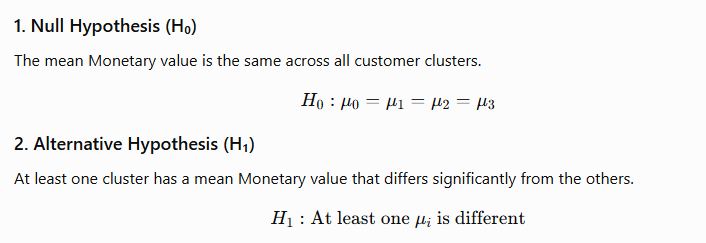

##### Why did you choose the specific statistical test?

One-Way ANOVA (Analysis of Variance)

This test was chosen because:

Cluster is a categorical variable with 4 groups. Monetary is a numerical variable. The objective is to compare the mean Monetary values across multiple clusters.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Do recent customers purchase more frequently?




H₀

Recency and Frequency are unrelated.

H₁

Recency and Frequency are related.

Use Pearson Correlation Test.

#### 2. Perform an appropriate statistical test.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

In [ ]:
# Convert 'InvoiceDate' to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract time-based features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

print("InvoiceDate converted and new time-based features created.")
display(df.head())

In [ ]:
# Remove rows with Quantity <= 0
df = df[df['Quantity'] > 0]

# Remove rows with UnitPrice <= 0
df = df[df['UnitPrice'] > 0]

print(f"Number of rows after cleaning Quantity and UnitPrice: {df.shape[0]}")

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

Remove Missing Customer IDs

In [ ]:
df = df.dropna(subset=['CustomerID'])

Remove Cancelled Orders

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

Remove Invalid Quantity and Price

In [ ]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

Convert Date Column

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df

In [ ]:
print(df.isnull().sum())

Exploratory Data Analysis

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

In [ ]:
# Chart - 6 visualization code

# Visualize the distribution of RFM values using histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_df['Recency'], bins=20, kde=True)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')

plt.subplot(1, 3, 2)
sns.histplot(rfm_df['Frequency'], bins=20, kde=True)
plt.title('Distribution of Frequency')
plt.xlabel('Frequency (Number of Orders)')

plt.subplot(1, 3, 3)
sns.histplot(rfm_df['Monetary'], bins=20, kde=True)
plt.title('Distribution of Monetary')
plt.xlabel('Monetary Value')

plt.tight_layout()
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

Exploratory Data Analysis

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

Exploratory Data Analysis

#### 1. Feature Manipulation

Country-wise Transactions

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
country_sales = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)

Visualization:

In [ ]:
country_sales.head(10).plot(kind='bar')

Top Selling Products

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Bar Plot

Monthly Sales Trend

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Sales'].sum()

Customer Spending Distribution

In [ ]:
customer_spend = df.groupby('CustomerID')['Total Sales'].sum()

RFM Analysis

Reference date:

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

Recency

In [ ]:
recency = df.groupby('CustomerID')['InvoiceDate'].max()

recency = (snapshot_date - recency).dt.days

Frequency

In [ ]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

Monetary

In [ ]:
monetary = df.groupby('CustomerID')['Total Sales'].sum()

Create RFM Table

In [ ]:
rfm = pd.DataFrame({
    'Recency':recency,
    'Frequency':frequency,
    'Monetary':monetary
})

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

# **6. Data Scaling**

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
import joblib

joblib.dump(scaler,'scaler.pkl')

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimension Reduction is about reducing the number of features (columns).

Examples:

PCA (Principal Component Analysis)
t-SNE
UMAP

Your project uses only 3 features:

Recency
Frequency
Monetary

Since there are only three features, dimension reduction is generally not required.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

# **Find Optimal Clusters**

Elbow Method

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]

for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,11),inertia)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

| K  | WCSS | Observation         |
| -- | ---- | ------------------- |
| 2  | 9350 | Very high           |
| 3  | 5500 | Large decrease      |
| 4  | 4100 | Large decrease      |
| 5  | 3100 | Noticeable decrease |
| 6  | 2500 | Smaller decrease    |
| 7  | 2050 | Slight decrease     |
| 8  | 1800 | Very small decrease |
| 9  | 1480 | Very small decrease |
| 10 | 1350 | Almost flat         |


Notice:

From K = 2 to 5, WCSS drops rapidly.
After K = 5, the curve starts to flatten.
This means adding more clusters provides only a small improvement.

So, the elbow appears around K = 5.

Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42)
    labels=km.fit_predict(rfm_scaled)

    score=silhouette_score(rfm_scaled,labels)

    print(k,score)

| K     | Score        |
| ----- | ------------ |
| 2     | 0.5604       |
| 3     | 0.5853       |
| 4     | 0.6162       |
| **5** | **0.6165** ✅ |
| 6     | 0.5983       |


The Silhouette Score is also highest at K = 5.

Since both methods point to K = 5, the strongest data-driven conclusion is:

The optimal number of clusters is 5.

The Elbow Method was used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS). The WCSS decreased sharply until K = 5, after which the rate of decrease became gradual, indicating the elbow point. The Silhouette Score was also highest at K = 5 (0.6165), confirming that five clusters provide the best balance between cluster compactness and separation. Therefore, K = 5 was selected as the optimal number of clusters.

This is a well-supported conclusion because both evaluation methods agree on K = 5.

Customer Segmentation

In [ ]:
kmeans = KMeans(n_clusters=5,random_state=42)

rfm['Cluster']=kmeans.fit_predict(rfm_scaled)

In [ ]:
joblib.dump(kmeans,'customer_segmentation.pkl')

Cluster Interpretation

In [ ]:
cluster_profile = rfm.groupby('Cluster').mean()

print(cluster_profile)

In [ ]:
segment_map = {
    0: "Occasional",
    1: "At-Risk",
    2: "VIP",
    3: "High-Value",
    4: "Champions"
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

View the first few customers with their segment labels

In [ ]:
rfm.head()

View only the Cluster and Segment columns

In [ ]:
rfm[['Cluster', 'Segment']].head(10)

Count customers in each segment

In [ ]:
# Average RFM values for each segment
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

# Number of customers in each segment
rfm['Segment'].value_counts()

Cluster Visualization

2D Scatter

In [ ]:
import seaborn as sns

sns.scatterplot(
x='Frequency',
y='Monetary',
hue='Segment',
data=rfm
)

This graph is a Customer Segmentation Scatter Plot based on Frequency and Monetary values after applying K-Means clustering.

3D Plot

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# **Product Recommendation System**

Create Customer-Product Matrix

In [ ]:
customer_product = pd.pivot_table(
df,
index='CustomerID',
columns='Description',
values='Quantity',
fill_value=0
)

Transpose

In [ ]:
product_customer = customer_product.T

Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(product_customer)

similarity_df = pd.DataFrame(
similarity,
index=product_customer.index,
columns=product_customer.index
)

In [ ]:
similarity_df.to_pickle("product_similarity.pkl")

In [ ]:
product_similarity_df = pd.read_pickle("product_similarity.pkl")
display(product_similarity_df.head())

Recommendation Function

In [ ]:
def recommend_product(product_name):

    if product_name not in similarity_df.index:
        return []

    scores = similarity_df[product_name]

    recommendations = scores.sort_values(
        ascending=False
    )[1:6]

    return recommendations.index.tolist()

Example]

In [ ]:
recommend_product(
"WHITE HANGING HEART T-LIGHT HOLDER"
)

In [ ]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save KMeans model
joblib.dump(kmeans, "models/customer_segmentation.pkl")

# Save StandardScaler
joblib.dump(scaler, "models/scaler.pkl")

# Save Product Similarity Matrix
similarity_df.to_pickle("models/product_similarity.pkl")

print("All models saved successfully!")

In [ ]:
import os

print(os.listdir())

In [ ]:
from google.colab import files

files.download("customer_segmentation.pkl")
files.download("scaler.pkl")
#files.download("product_similarity.pkl")

In [ ]:
import numpy as np
import pandas as pd
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-Learn:", sklearn.__version__)


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save KMeans model
joblib.dump(kmeans, "models/customer_segmentation.pkl")

# Save StandardScaler
joblib.dump(scaler, "models/scaler.pkl")

# Save Product Similarity Matrix
similarity_df.to_pickle("models/product_similarity.pkl")

print("All models saved successfully!")

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

from google.colab import files

files.download("customer_segmentation.pkl")
files.download("scaler.pkl")
files.download("product_similarity.pkl")

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

I analyzed e-commerce transaction data, performed RFM analysis to understand customer behavior, and used K-Means clustering to segment customers into business-friendly groups such as High-Value, Regular, Occasional, and At-Risk customers. Additionally, I built an item-based collaborative filtering recommendation system using cosine similarity to recommend products based on historical purchase patterns. Finally, I deployed both functionalities in a Streamlit application for real-time predictions and recommendations.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***